
# Lab 5: Scrodinger equation with FDM

Ross Anthony Miranda D'Angelo

 **Exercise** : Solve the radial Schrodinger for Hydrogen atom with FDM

 ### Hydrogen radial equation

The H atom has an electron of mass $m$ a $r$ distance to the pronton. The potential energy is given by

$U(r)= -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}$

The Schrodinger's equation for this system is

$$
-\dfrac{\hbar^2}{2m}\nabla^2 \psi(\vec{r}) + -\dfrac{e^2}{4\pi\epsilon_0}\dfrac{1}{r}\psi(\vec{r})= E\,\psi(\vec{r})$$

In [1]:
# Librerías
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as spe

In [2]:
# Parámetros del problema en unidades atómicas
# En estas unidades:
# hbar = 1
# m = 1
# e^2/(4*pi*epsilon_0) = 1
# a_0 = 1

hbar = 1.0
m = 1.0

r_max = 30.0       # radio máximo [a0]
N = 1000           # número de puntos interiores

dr = r_max / (N + 1)
r = np.arange(1, N + 1) * dr

print(f"dr = {dr:.6f} a0")
print(f"N = {N}")
print(f"r_max = {r_max} a0")

dr = 0.029970 a0
N = 1000
r_max = 30.0 a0


In [3]:
def V_eff(r, l):
    """
    Potencial efectivo radial del átomo de hidrógeno
    en unidades atómicas.
    """
    return -1.0/r + l*(l+1)/(2.0*r**2)

In [4]:
def hamiltonian_hydrogen(N, r, dr, l):
    """
    Construye la matriz Hamiltoniana radial
    mediante diferencias finitas.
    """

    V = V_eff(r, l)

    # Diagonal principal
    diag = 1.0/dr**2 + V

    # Diagonales secundarias
    off_diag = -1.0/(2.0*dr**2) * np.ones(N-1)

    # Hamiltoniano
    H = (
        np.diag(diag)
        + np.diag(off_diag, 1)
        + np.diag(off_diag, -1)
    )

    return H

In [5]:
l = 0

H = hamiltonian_hydrogen(N, r, dr, l)

# Resolver:
# H u = E u
E, u = np.linalg.eigh(H)

print("Primeros niveles de energía:")
for i in range(5):
    print(f"E_{i+1} = {E[i]:.8f} Ha")

Primeros niveles de energía:
E_1 = -0.49988778 Ha
E_2 = -0.12499298 Ha
E_3 = -0.05542226 Ha
E_4 = -0.02463843 Ha
E_5 = 0.01331489 Ha


In [6]:
# Normalización de los primeros estados
num_states = 5

for n in range(num_states):
    norm = np.sqrt(np.trapezoid(u[:, n]**2, x=r))
    u[:, n] /= norm

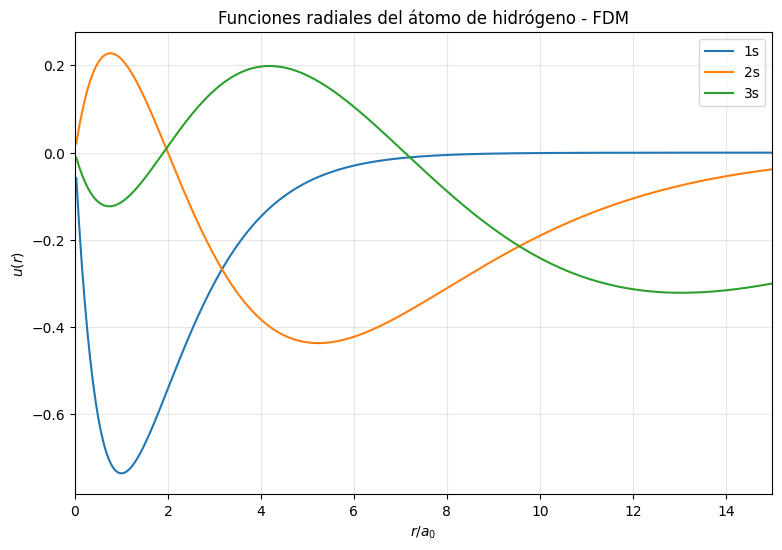

In [7]:
plt.figure(figsize=(9, 6))

for n in range(3):
    plt.plot(r, u[:, n], label=f'{n+1}s')

plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$u(r)$')
plt.title('Funciones radiales del átomo de hidrógeno - FDM')
plt.xlim(0, 15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

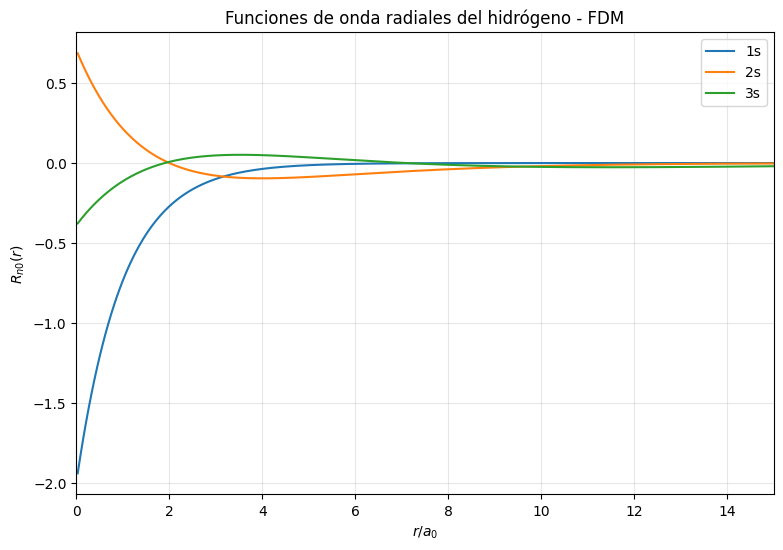

In [8]:
R_fdm = u / r[:, None]

plt.figure(figsize=(9, 6))

for n in range(3):
    plt.plot(r, R_fdm[:, n], label=f'{n+1}s')

plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$R_{n0}(r)$')
plt.title('Funciones de onda radiales del hidrógeno - FDM')
plt.xlim(0, 15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [9]:
def psi_R(r, n=1, l=0):
    """
    Función radial analítica R_nl(r)
    en unidades atómicas.
    """

    coeff = np.sqrt(
        (2.0/n)**3
        * spe.factorial(n-l-1)
        / (2.0*n*spe.factorial(n+l))
    )

    rho = 2.0*r/n

    laguerre = spe.assoc_laguerre(
        rho,
        n-l-1,
        2*l+1
    )

    return (
        coeff
        * np.exp(-r/n)
        * rho**l
        * laguerre
    )

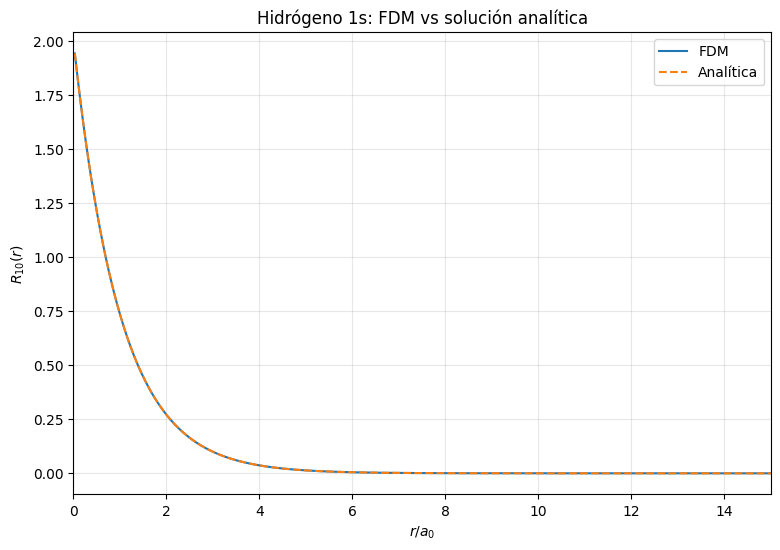

In [10]:
# Solución analítica
R_exact = psi_R(r, n=1, l=0)

# Solución FDM
R_fdm_1s = R_fdm[:, 0].copy()

# El signo global del autovector es arbitrario
if np.dot(R_fdm_1s, R_exact) < 0:
    R_fdm_1s *= -1

plt.figure(figsize=(9, 6))

plt.plot(r, R_fdm_1s, label='FDM')
plt.plot(r, R_exact, '--', label='Analítica')

plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$R_{10}(r)$')
plt.title('Hidrógeno 1s: FDM vs solución analítica')
plt.xlim(0, 15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

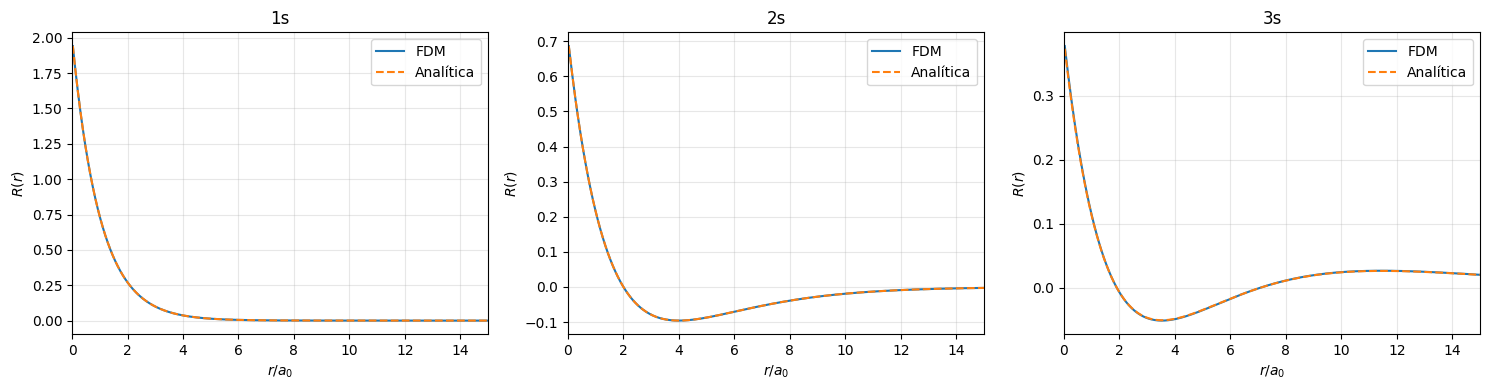

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for i, n in enumerate([1, 2, 3]):

    R_num = R_fdm[:, i].copy()
    R_exact = psi_R(r, n=n, l=0)

    # Ajustar el signo global
    if np.dot(R_num, R_exact) < 0:
        R_num *= -1

    ax[i].plot(r, R_num, label='FDM')
    ax[i].plot(r, R_exact, '--', label='Analítica')

    ax[i].set_title(f'{n}s')
    ax[i].set_xlabel(r'$r/a_0$')
    ax[i].set_ylabel(r'$R(r)$')
    ax[i].set_xlim(0, 15)
    ax[i].grid(alpha=0.3)
    ax[i].legend()

plt.tight_layout()
plt.show()

In [12]:
n_values = np.arange(1, 6)

E_analytical = -1.0/(2.0*n_values**2)

print("Comparación de energías")
print("-"*50)
print(" n       FDM [Ha]       Analítica [Ha]       Error [%]")
print("-"*50)

for i, n in enumerate(n_values):

    E_num = E[i]
    E_exact = E_analytical[i]

    error = abs((E_num - E_exact)/E_exact)*100

    print(
        f"{n:2d}   "
        f"{E_num:12.8f}   "
        f"{E_exact:15.8f}   "
        f"{error:10.5f}"
    )

Comparación de energías
--------------------------------------------------
 n       FDM [Ha]       Analítica [Ha]       Error [%]
--------------------------------------------------
 1    -0.49988778       -0.50000000      0.02244
 2    -0.12499298       -0.12500000      0.00562
 3    -0.05542226       -0.05555556      0.23994
 4    -0.02463843       -0.03125000     21.15704
 5     0.01331489       -0.02000000    166.57446


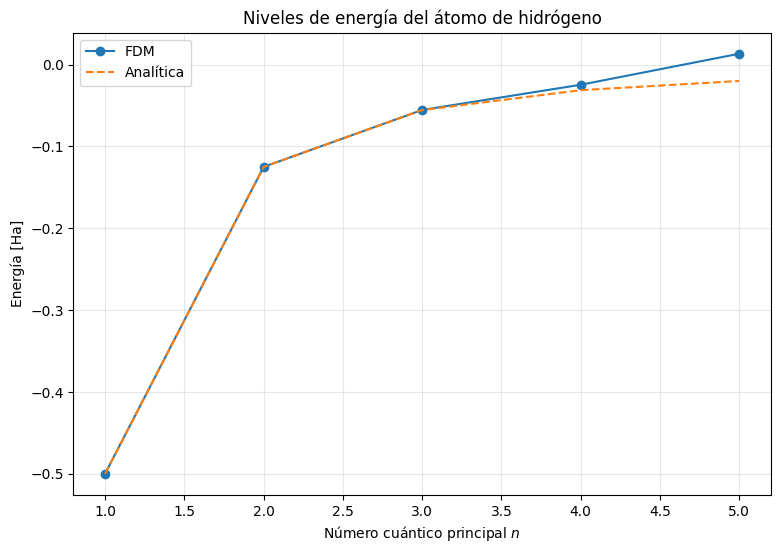

In [13]:
plt.figure(figsize=(9, 6))

plt.plot(
    n_values,
    E[:5],
    'o-',
    label='FDM'
)

plt.plot(
    n_values,
    E_analytical,
    '--',
    label='Analítica'
)

plt.xlabel('Número cuántico principal $n$')
plt.ylabel('Energía [Ha]')
plt.title('Niveles de energía del átomo de hidrógeno')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [14]:
l = 1

H_l1 = hamiltonian_hydrogen(N, r, dr, l)

E_l1, u_l1 = np.linalg.eigh(H_l1)

# Normalizar los primeros estados
for n in range(3):
    norm = np.sqrt(np.trapezoid(u_l1[:, n]**2, x=r))
    u_l1[:, n] /= norm

print("Primeros estados para l = 1:")

for i in range(3):
    print(f"Estado {i+1}: E = {E_l1[i]:.8f} Ha")

Primeros estados para l = 1:
Estado 1: E = -0.12500234 Ha
Estado 2: E = -0.05547238 Ha
Estado 3: E = -0.02591505 Ha


In [15]:
# Energía del 2s obtenida anteriormente
E_2s = E[1]

# Energía del 2p
E_2p = E_l1[0]

print(f"E(2s) = {E_2s:.8f} Ha")
print(f"E(2p) = {E_2p:.8f} Ha")
print(f"Diferencia = {abs(E_2s-E_2p):.8e} Ha")

E(2s) = -0.12499298 Ha
E(2p) = -0.12500234 Ha
Diferencia = 9.35798703e-06 Ha


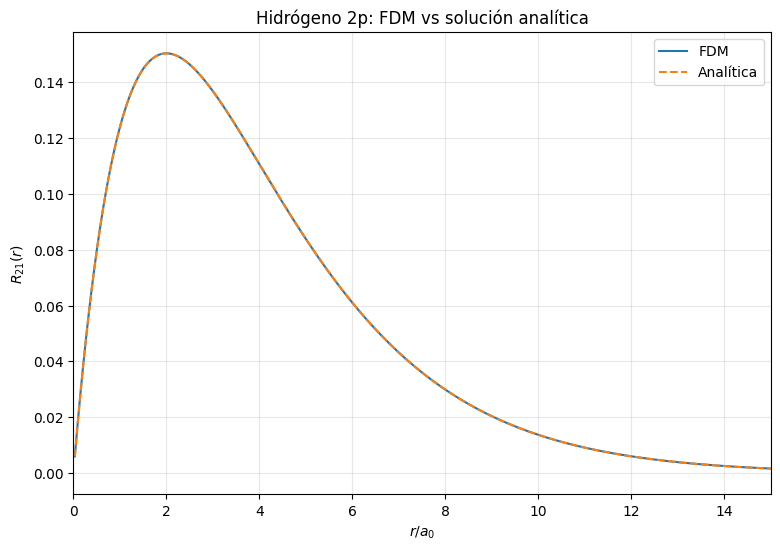

In [16]:
R_2p_fdm = u_l1[:, 0] / r

R_2p_exact = psi_R(r, n=2, l=1)

# Ajustar el signo
if np.dot(R_2p_fdm, R_2p_exact) < 0:
    R_2p_fdm *= -1

plt.figure(figsize=(9, 6))

plt.plot(r, R_2p_fdm, label='FDM')
plt.plot(r, R_2p_exact, '--', label='Analítica')

plt.xlabel(r'$r/a_0$')
plt.ylabel(r'$R_{21}(r)$')
plt.title('Hidrógeno 2p: FDM vs solución analítica')
plt.xlim(0, 15)
plt.grid(alpha=0.3)
plt.legend()
plt.show()